In [2]:
%matplotlib widget
import inspect
import re
def debugPrint(x):
    frame = inspect.currentframe().f_back
    s = inspect.getframeinfo(frame).code_context[0]
    r = re.search(r"\((.*)\)", s).group(1)
    print("{} [{}] = {}".format(r,type(x).__name__, x))
       
import torch
import numpy as np
import warp as wp

# Initialize Warp
wp.config.verify_autograd_array_access = False
wp.config.verbose = False
wp.init()

from sphWarpCore import radiusSearchCompactHashMap, sphOperation_warp
from sphWarpCore.enumTypes import *

from diffSPH.neighborhood import buildNeighborhood
from diffSPH.operations import SPHOperation
from diffSPH.enums import Operation, SupportScheme, GradientMode, LaplacianMode
from diffSPH.operations import KernelCorrectionScheme
from diffSPH.kernels import *
from diffSPH.plotting import visualizeParticles
from diffSPH.kernels import getSPHKernelv2

import matplotlib.pyplot as plt
from demo_util import *

Warp 1.12.0 initialized:
   CUDA Toolkit 12.9, Driver 13.2
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "NVIDIA RTX PRO 500 Blackwell Generation Laptop GPU" (6 GiB, sm_120, mempool enabled)
   Kernel cache:
     /home/lu26029/.cache/warp/1.12.0


In [3]:
device = torch.device('cpu')
device = torch.device('cuda')
targetNumNeighbors = 50
nx = 128
dim = 2
numParticles = nx**dim

warpOnly = False
periodic = True

queryPositions, referencePositions, \
        querySupports, referenceSupports, \
        queryMasses, referenceMasses, \
        queryDensities, referenceDensities, \
        domain, adjacency, neighborhood, simulationState, measurements = prepData(nx, targetNumNeighbors, dim, device, periodic, warpOnly, noiseAmplitude = 0.0)

markerSize = 8 if warpOnly else 2
gridVisualization = False 
gridResolution = 128
def plotToAxis(fig, axis, quantity, title, cmap, mask = None):
    return visualizeParticles(
        fig, axis,
        PlotSet(
            positions = queryPositions[mask] if mask is not None else queryPositions,
            supports = querySupports[mask] if mask is not None else querySupports,
            masses = queryMasses[mask] if mask is not None else queryMasses,
            densities = queryDensities[mask] if mask is not None else queryDensities,
            kinds = torch.zeros(queryPositions.shape[0], dtype = torch.long, device=queryPositions.device)[mask] if mask is not None else torch.zeros(queryPositions.shape[0], dtype = torch.long, device=queryPositions.device)
        ),
        quantity = quantity[mask] if mask is not None else quantity,
        kernel = KernelType.Wendland2,
        domain = domain,

        cmap = cmap,
        markerSize = markerSize,
        gridVisualization = gridVisualization,
        gridResolution = gridResolution,

        streamLines = False,
        plotDomain = True,
        title = title,
    )

Module sphWarpCore.radiusSearch.wp_compactHash e2c9126 load on device 'cuda:0' took 6.86 ms  (cached)
Module sphWarpCore.operations.wp_density 414a5a1 load on device 'cuda:0' took 6.15 ms  (cached)


In [4]:
f = torch.sin(queryPositions[:,0] * 2 * np.pi) # * torch.sin(queryPositions[:,1] * 2 * np.pi)
f_laplacian = -4 * np.pi**2 * f

In [11]:
laplacian_warp = sphOperation_warp(
    queryPositions, referencePositions,
    querySupports, referenceSupports,
    queryMasses, referenceMasses,
    queryDensities, referenceDensities,
    f, f,
    domain = domain, adjacency = adjacency, 
    operation = WarpOperation.Laplacian, operationMode = OperationDirection.AllToAll,
    kernel = KernelFunctions.Wendland2, supportMode = SupportScheme.SuperSymmetric,
    laplacianMode=LaplacianMode.Brookshaw,
    gradientMode = GradientScheme.Difference
)

if not warpOnly:
    laplacian_diffSPH = SPHOperation(
        simulationState,
        quantity = f,
        kernel = KernelType.Wendland2,
        neighborhood = neighborhood[0],
        kernelValues = neighborhood[1],
        operation=Operation.Laplacian,
        gradientMode=GradientMode.Difference,
        supportScheme = SupportScheme.SuperSymmetric,
        correctionTerms= [],
        positiveDivergence=False
    )



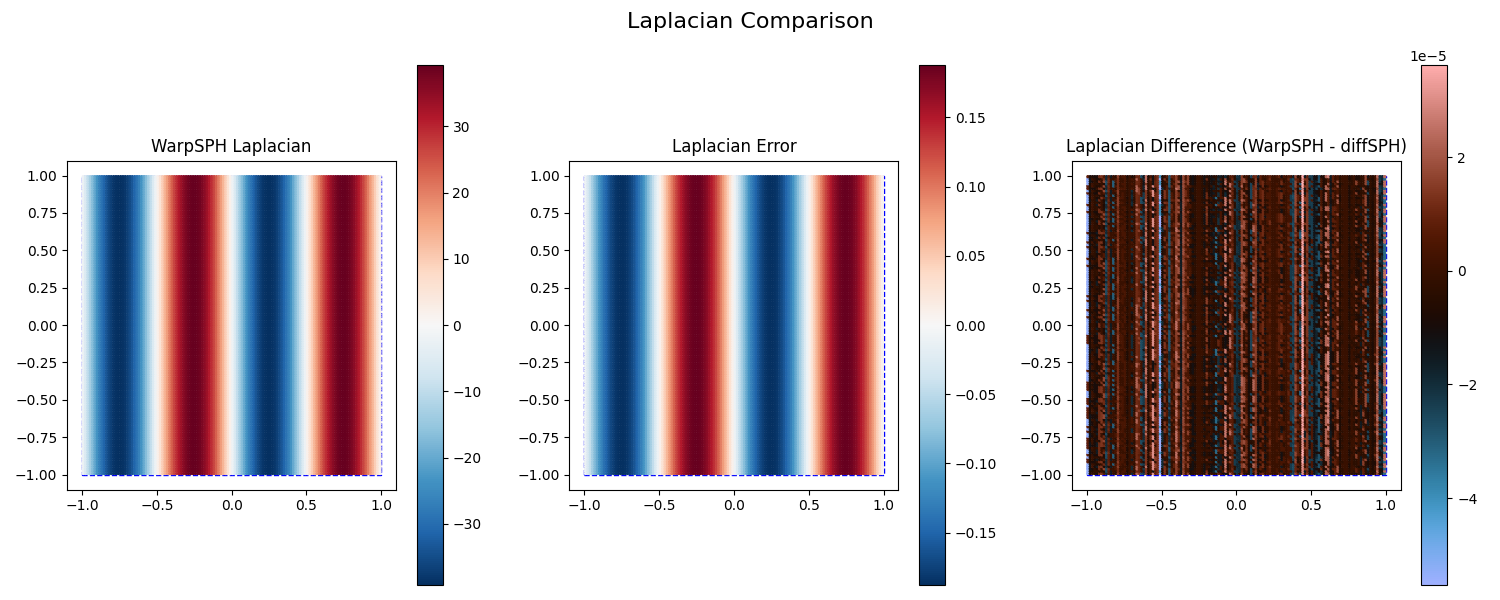

In [12]:
fig, axis = plt.subplots(1,3 if not warpOnly else 2, figsize = (15 if not warpOnly else 11,6), squeeze=False)
markerSize = 8 if warpOnly else 2
gridVisualization = False 
gridResolution = 128


plotToAxis(fig, axis[0,0], laplacian_warp, "WarpSPH Laplacian", 'RdBu_r')

plotToAxis(fig, axis[0,1], f_laplacian - laplacian_warp, "Laplacian Error", 'RdBu_r')

if not warpOnly:
    # plotToAxis(fig, axis[0,1], laplacian_diffSPH, "diffSPH Laplacian", 'RdBu_r')

    diff_x = laplacian_warp - laplacian_diffSPH

    plotToAxis(fig, axis[0,2], diff_x, "Laplacian Difference (WarpSPH - diffSPH)", 'berlin')

fig.suptitle("Laplacian Comparison" if not warpOnly else "WarpSPH Laplacian", fontsize = 16)
fig.tight_layout()
